# Renewable Energy Forecasting — Phase 2: Exploratory Data Analysis
### Shell Internship Project

In this notebook we will:
1. Understand the distribution of solar and wind output
2. Explore seasonality — hourly, daily, and monthly patterns
3. Analyse correlations between weather features and energy output
4. Spot and flag outliers
5. Check stationarity (required before SARIMA modelling)

All plots here will feed directly into the Streamlit dashboard in Phase 4.

## 0. Imports & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

# Load the CSV saved in Phase 1
df = pd.read_csv('data/energy_weather_london.csv', index_col='time', parse_dates=True)

print('Shape:', df.shape)
print('Date range:', df.index.min(), '->', df.index.max())
df.head()

Shape: (43824, 16)
Date range: 2019-01-01 00:00:00 -> 2023-12-31 23:00:00


,solar_cf,wind_cf,temp_c,cloud_cover_pct,wind_speed_ms,wind_dir_deg,radiation_wm2,hour,day_of_week,month,day_of_year,year,hour_sin,hour_cos,month_sin,month_cos
time,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.0,0.261,6.8,82,2.86,258,0.0,0,1,1,1,2019,0.000000,1.000000,0.5,0.866025
2019-01-01 01:00:00,0.0,0.264,7.0,65,3.26,259,0.0,1,1,1,1,2019,0.258819,0.965926,0.5,0.866025
2019-01-01 02:00:00,0.0,0.260,6.6,24,3.18,257,0.0,2,1,1,1,2019,0.500000,0.866025,0.5,0.866025
2019-01-01 03:00:00,0.0,0.261,5.7,8,2.93,262,0.0,3,1,1,1,2019,0.707107,0.707107,0.5,0.866025
2019-01-01 04:00:00,0.0,0.268,5.0,1,3.22,263,0.0,4,1,1,1,2019,0.866025,0.500000,0.5,0.866025


## 1. Distribution of Solar vs Wind Output

Understanding the shape of your target variable is always step one.

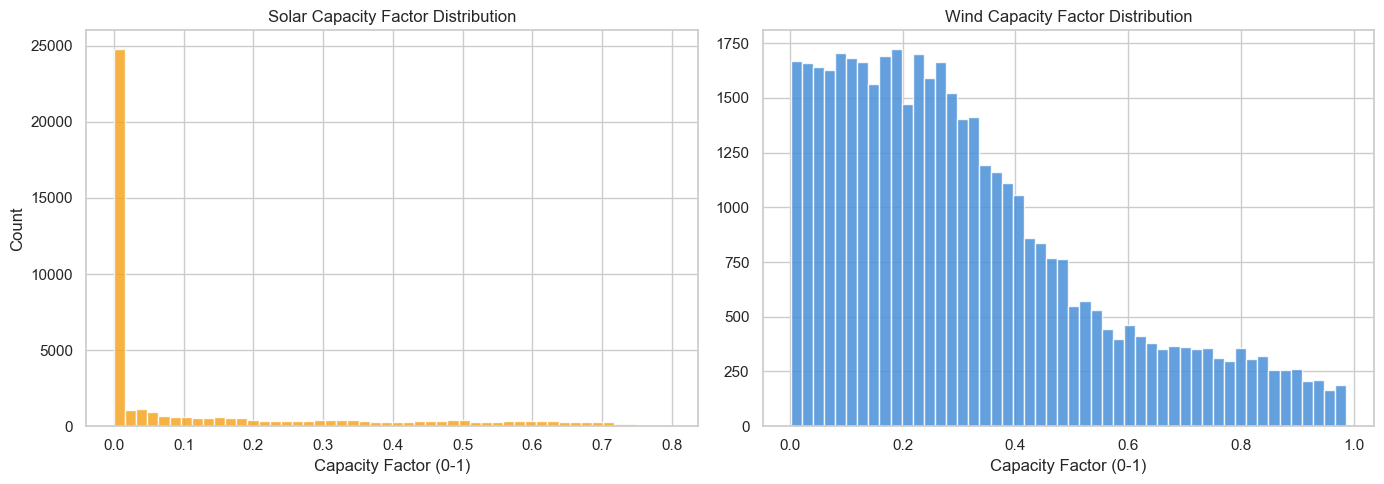

           solar_cf       wind_cf
count  43824.000000  43824.000000
mean       0.132928      0.313687
std        0.208818      0.233594
min        0.000000      0.001000
25%        0.000000      0.131000
50%        0.000000      0.264000
75%        0.206000      0.436000
max        0.797000      0.987000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['solar_cf'], bins=50, color='#f5a623', edgecolor='white', alpha=0.85)
axes[0].set_title('Solar Capacity Factor Distribution')
axes[0].set_xlabel('Capacity Factor (0-1)')
axes[0].set_ylabel('Count')

axes[1].hist(df['wind_cf'], bins=50, color='#4a90d9', edgecolor='white', alpha=0.85)
axes[1].set_title('Wind Capacity Factor Distribution')
axes[1].set_xlabel('Capacity Factor (0-1)')

plt.tight_layout()
plt.savefig('data/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['solar_cf', 'wind_cf']].describe())

## 2. Hourly Seasonality

What time of day does each source peak? Solar should peak midday, wind should be flatter.

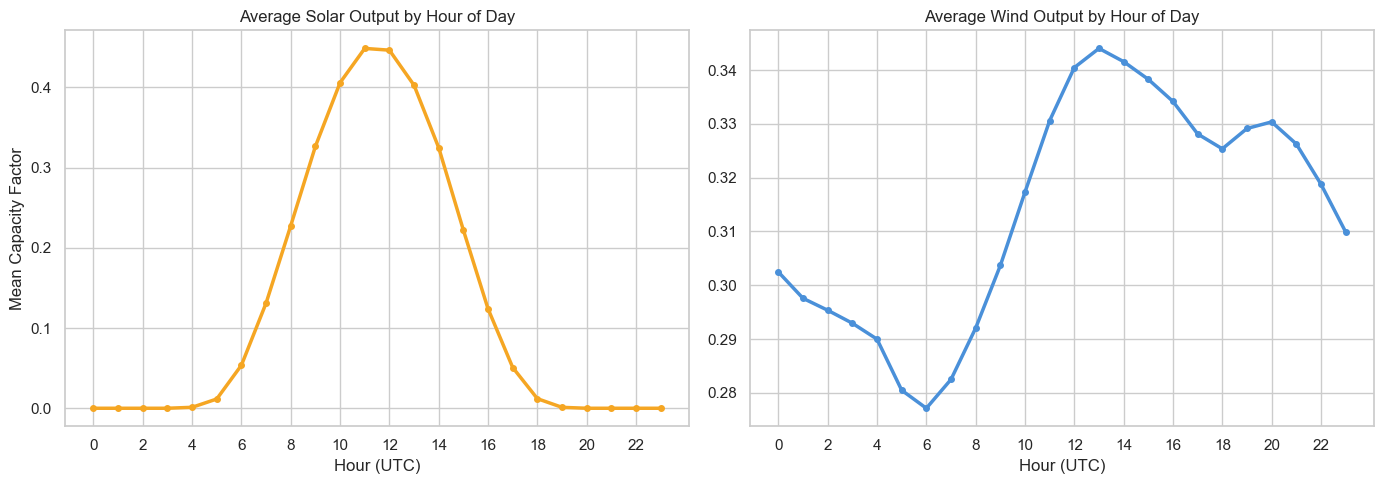

In [7]:
hourly = df.groupby(df.index.hour)[['solar_cf', 'wind_cf']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly.index, hourly['solar_cf'], color='#f5a623', linewidth=2.5, marker='o', markersize=4)
axes[0].set_title('Average Solar Output by Hour of Day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Mean Capacity Factor')
axes[0].set_xticks(range(0, 24, 2))

axes[1].plot(hourly.index, hourly['wind_cf'], color='#4a90d9', linewidth=2.5, marker='o', markersize=4)
axes[1].set_title('Average Wind Output by Hour of Day')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('data/eda_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Monthly Seasonality

Solar peaks in summer, wind peaks in winter — this is the classic UK complementarity.

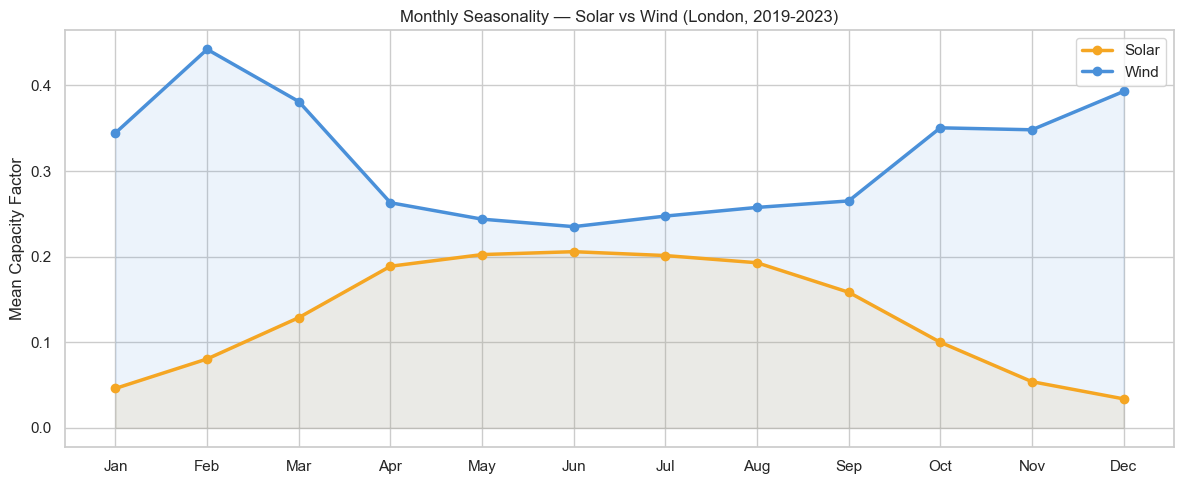

In [9]:
monthly = df.groupby(df.index.month)[['solar_cf', 'wind_cf']].mean()
monthly = monthly.reindex(range(1, 13))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(12), monthly['solar_cf'].values, color='#f5a623', linewidth=2.5,
        marker='o', markersize=6, label='Solar')
ax.plot(range(12), monthly['wind_cf'].values,  color='#4a90d9', linewidth=2.5,
        marker='o', markersize=6, label='Wind')
ax.fill_between(range(12), monthly['solar_cf'].values, alpha=0.1, color='#f5a623')
ax.fill_between(range(12), monthly['wind_cf'].values,  alpha=0.1, color='#4a90d9')
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean Capacity Factor')
ax.set_title('Monthly Seasonality — Solar vs Wind (London, 2019-2023)')
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Combined Output — The Complementarity Story

This is a key insight for the project: solar and wind complement each other.
When one is low, the other tends to compensate.

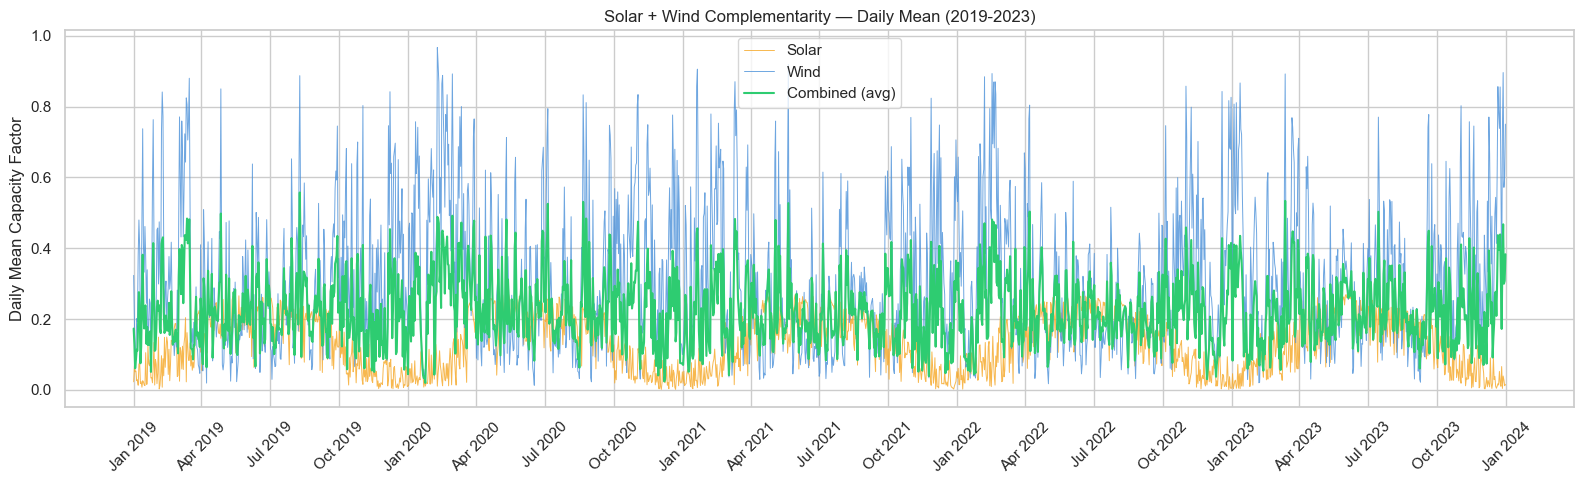

In [11]:
df['combined_cf'] = (df['solar_cf'] + df['wind_cf']) / 2

daily = df[['solar_cf', 'wind_cf', 'combined_cf']].resample('D').mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily.index, daily['solar_cf'],   color='#f5a623', linewidth=0.7, alpha=0.8, label='Solar')
ax.plot(daily.index, daily['wind_cf'],    color='#4a90d9', linewidth=0.7, alpha=0.8, label='Wind')
ax.plot(daily.index, daily['combined_cf'],color='#2ecc71', linewidth=1.5, label='Combined (avg)')
ax.set_ylabel('Daily Mean Capacity Factor')
ax.set_title('Solar + Wind Complementarity — Daily Mean (2019-2023)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_complementarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

Which weather features most strongly predict solar and wind output?

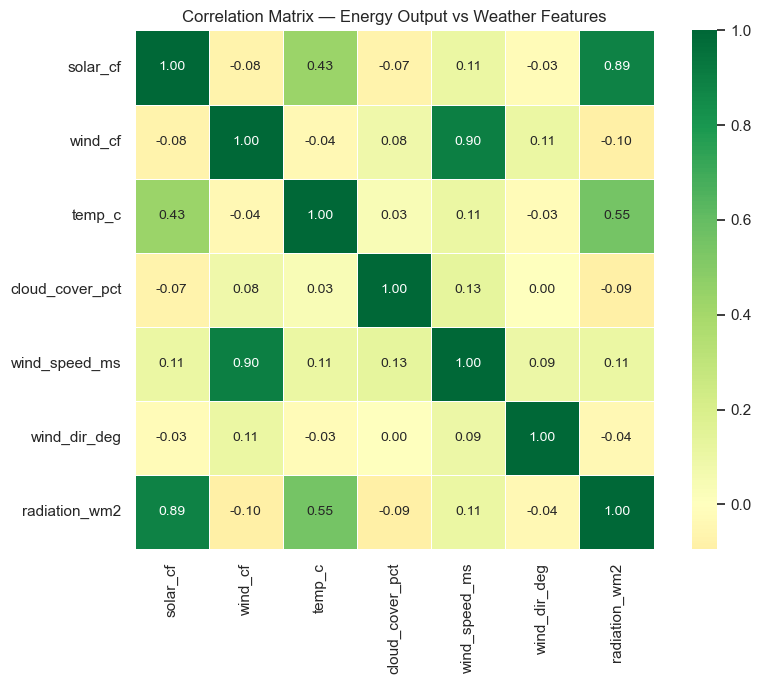

In [13]:
cols_of_interest = [
    'solar_cf', 'wind_cf',
    'temp_c', 'cloud_cover_pct', 'wind_speed_ms',
    'wind_dir_deg', 'radiation_wm2'
]

corr = df[cols_of_interest].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, square=True, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Correlation Matrix — Energy Output vs Weather Features')
plt.tight_layout()
plt.savefig('data/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Scatter Plots — Key Relationships

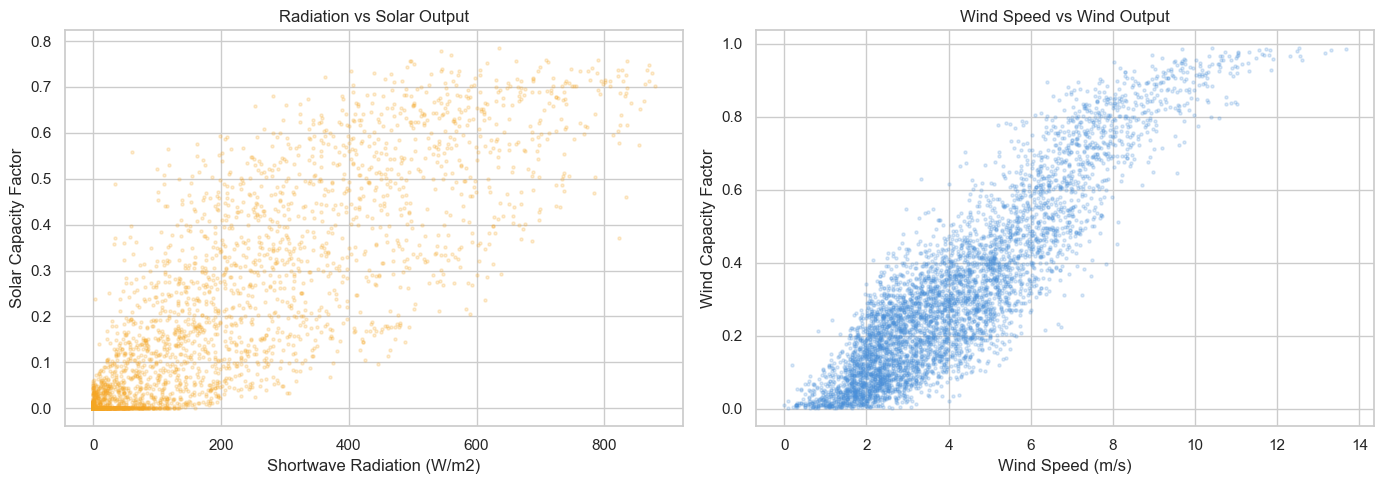

In [15]:
# Sample 5000 points so the plot isn't too heavy
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['radiation_wm2'], sample['solar_cf'],
                alpha=0.2, s=5, color='#f5a623')
axes[0].set_xlabel('Shortwave Radiation (W/m2)')
axes[0].set_ylabel('Solar Capacity Factor')
axes[0].set_title('Radiation vs Solar Output')

axes[1].scatter(sample['wind_speed_ms'], sample['wind_cf'],
                alpha=0.2, s=5, color='#4a90d9')
axes[1].set_xlabel('Wind Speed (m/s)')
axes[1].set_ylabel('Wind Capacity Factor')
axes[1].set_title('Wind Speed vs Wind Output')

plt.tight_layout()
plt.savefig('data/eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Outlier Detection

Flag rows where capacity factor is suspiciously high or low.

In [17]:
def flag_outliers(series, name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}: {len(outliers)} outliers ({len(outliers)/len(series)*100:.2f}%)')
    print(f'  IQR bounds: [{lower:.4f}, {upper:.4f}]')
    return outliers

solar_outliers = flag_outliers(df['solar_cf'], 'Solar CF')
wind_outliers  = flag_outliers(df['wind_cf'],  'Wind CF')

Solar CF: 0 outliers (0.00%)
  IQR bounds: [-0.6180, 0.8240]
Wind CF: 0 outliers (0.00%)
  IQR bounds: [-0.7840, 1.3510]


## 8. Stationarity Check (ADF Test)

SARIMA requires stationary data. The Augmented Dickey-Fuller test checks this formally.

- **p-value < 0.05** → stationary (good, can model directly)
- **p-value >= 0.05** → non-stationary (need differencing)

In [19]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- ADF Test: {name} ---')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.6f}')
    print(f'  Stationary    : {"YES" if result[1] < 0.05 else "NO — will need differencing"}')
    print()

# Use a daily resample for this test — hourly is too granular for SARIMA
daily = df[['solar_cf', 'wind_cf']].resample('D').mean()

adf_test(daily['solar_cf'], 'Solar CF (daily mean)')
adf_test(daily['wind_cf'],  'Wind CF (daily mean)')

--- ADF Test: Solar CF (daily mean) ---
  ADF Statistic : -2.5286
  p-value       : 0.108663
  Stationary    : NO — will need differencing

--- ADF Test: Wind CF (daily mean) ---
  ADF Statistic : -10.8171
  p-value       : 0.000000
  Stationary    : YES



## 9. ACF & PACF Plots

These tell us how many lag terms (p, q) to use in SARIMA.
- **ACF** → guides the MA(q) order
- **PACF** → guides the AR(p) order

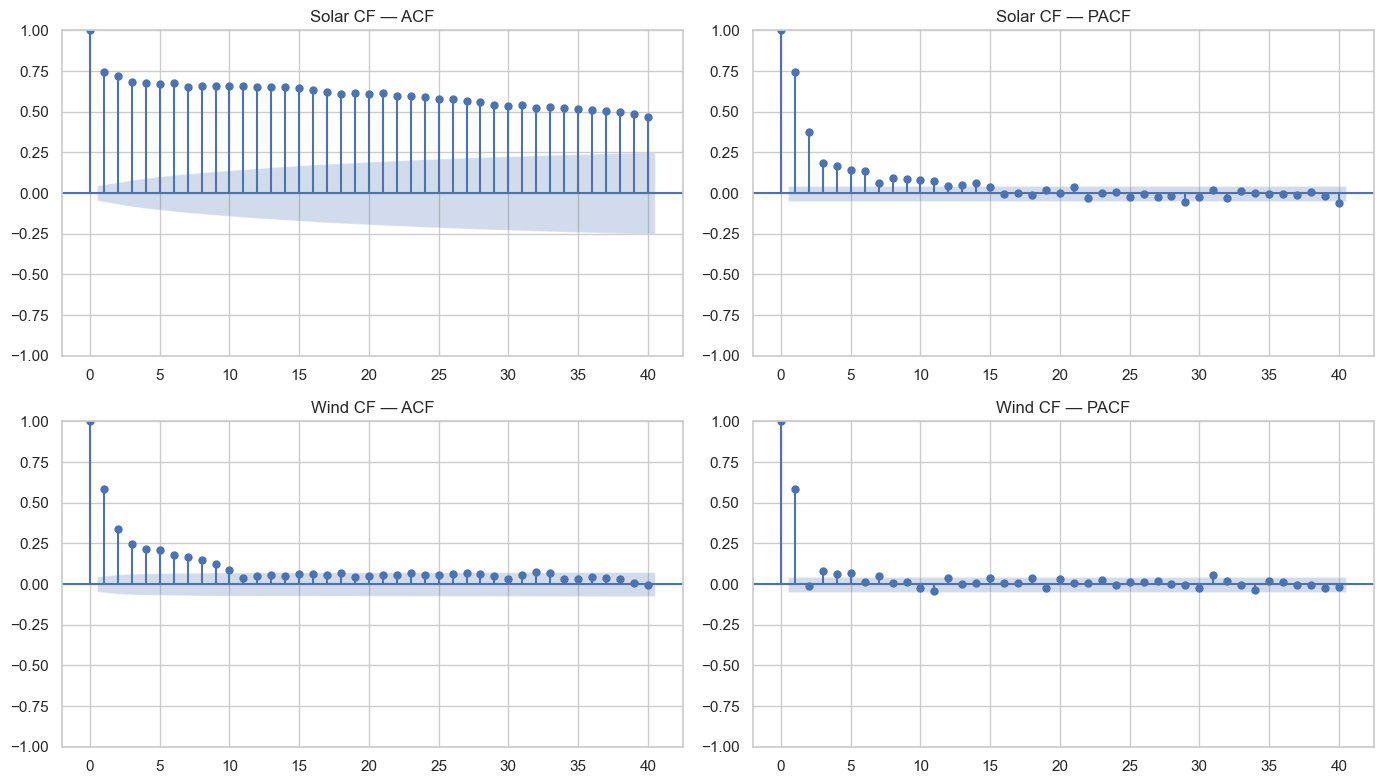

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( daily['solar_cf'].dropna(), lags=40, ax=axes[0][0], title='Solar CF — ACF')
plot_pacf(daily['solar_cf'].dropna(), lags=40, ax=axes[0][1], title='Solar CF — PACF')
plot_acf( daily['wind_cf'].dropna(),  lags=40, ax=axes[1][0], title='Wind CF — ACF')
plot_pacf(daily['wind_cf'].dropna(),  lags=40, ax=axes[1][1], title='Wind CF — PACF')

plt.tight_layout()
plt.savefig('data/eda_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Daily Dataset for Modelling

SARIMA and Prophet work better on daily aggregates than raw hourly data.
We save a separate daily CSV that Phase 3 will use.

In [23]:
daily_full = df.resample('D').mean()
daily_full.to_csv('data/daily_energy_weather_london.csv')

print('Daily dataset saved.')
print('Shape:', daily_full.shape)
daily_full.head()

Daily dataset saved.
Shape: (1826, 17)


,solar_cf,wind_cf,temp_c,cloud_cover_pct,wind_speed_ms,wind_dir_deg,radiation_wm2,hour,day_of_week,month,day_of_year,year,hour_sin,hour_cos,month_sin,month_cos,combined_cf
time,,,,,,,,,,,,,,,,,
2019-01-01,0.022583,0.323208,6.837500,44.166667,3.531667,231.166667,37.125000,11.5,1.0,1.0,1.0,2019.0,-4.625929e-18,-5.551115e-17,0.5,0.866025,0.172896
2019-01-02,0.067750,0.189208,3.683333,71.500000,2.475417,348.666667,29.541667,11.5,2.0,1.0,2.0,2019.0,-4.625929e-18,-5.551115e-17,0.5,0.866025,0.128479
2019-01-03,0.051000,0.070625,1.950000,57.958333,1.658333,169.208333,34.750000,11.5,3.0,1.0,3.0,2019.0,-4.625929e-18,-5.551115e-17,0.5,0.866025,0.060812
2019-01-04,0.053042,0.116333,-0.533333,58.666667,1.812083,261.458333,42.750000,11.5,4.0,1.0,4.0,2019.0,-4.625929e-18,-5.551115e-17,0.5,0.866025,0.084688
2019-01-05,0.025625,0.201000,1.908333,52.791667,2.404167,286.208333,44.708333,11.5,5.0,1.0,5.0,2019.0,-4.625929e-18,-5.551115e-17,0.5,0.866025,0.113312


---
## Phase 2 Complete!

**Key findings to note for your write-up:**
- Solar and wind show strong inverse seasonality (solar peaks summer, wind peaks winter)
- `radiation_wm2` is the strongest predictor of solar output
- `wind_speed_ms` is the strongest predictor of wind output
- Cloud cover negatively correlates with solar
- Both series are stationary at daily level (check your ADF results above)

**Next up: Phase 3 — Modelling with SARIMA and Prophet**